In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split

In [3]:
import dtale
import pickle, joblib
from sqlalchemy import create_engine, text
from urllib.parse import quote

In [4]:
# Creating engine which connect to MySQL
# Add Mysql Database credentials
user = 'root' # user name
pw = 'bane2804' # password
db = 'projectml' # database

In [5]:
# creating engine to connect database
engine = create_engine(f"mysql+pymysql://{user}:%s@localhost/{db}" %quote(f'{pw}'))

In [6]:
#lets import the data
data = pd.read_csv(r"prima_13.csv")

In [7]:
# dumping data into database 
data.to_sql('prima_13', con = engine, if_exists = 'replace', chunksize = 1000, index = False)

2700

In [8]:
# loading data from database
sql = text('select * from prima_13')
df = pd.read_sql_query(sql, con = engine.connect())

In [9]:
print(df)

            Date         Machine_ID  Load_cells  Hydraulic_Pressure(bar)  \
0       1/1/2022  PRIMA-13-L1-Unit1    7.187623                 5.000000   
1       1/1/2022  PRIMA-13-L1-Unit1    1.721361                 1.877699   
2       1/1/2022  PRIMA-13-L1-Unit1    5.320743                29.218349   
3       1/1/2022  PRIMA-13-L1-Unit1    6.676239                 5.000000   
4       1/1/2022  PRIMA-13-L1-Unit1    4.856218                22.589263   
...          ...                ...         ...                      ...   
2695  31-12-2022  PRIMA-13-L1-Unit1   13.045980               423.181065   
2696  31-12-2022  PRIMA-13-L1-Unit1   15.470337               521.588413   
2697  31-12-2022  PRIMA-13-L1-Unit1    5.512085               584.390344   
2698    1/1/2023  PRIMA-13-L1-Unit1   11.485721               417.797433   
2699    1/1/2023  PRIMA-13-L1-Unit1   15.727231               471.411420   

      Coolant_Pressure(bar)  Air_System_Pressure(bar)  \
0                  4.805257   

In [10]:
df.info()
# autoeda
dtale.show(df).open_browser()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           2700 non-null   object 
 1   Machine_ID                     2700 non-null   object 
 2   Load_cells                     2680 non-null   float64
 3   Hydraulic_Pressure(bar)        2694 non-null   float64
 4   Coolant_Pressure(bar)          2700 non-null   float64
 5   Air_System_Pressure(bar)       2700 non-null   float64
 6   Coolant_Temperature(°C)        2700 non-null   float64
 7   Hydraulic_Oil_Temperature(°C)  2700 non-null   float64
 8   Proximity_sensors              2680 non-null   float64
 9   Spindle_Vibration(µm)          2700 non-null   float64
 10  Tool_Vibration(µm)             2700 non-null   float64
 11  Spindle_Speed(RPM)             2694 non-null   float64
 12  Voltage(volts)                 2700 non-null   f

In [11]:
#Descriptive Analytics
desc = df.describe()

In [12]:
# Datapreprocessing by Pipeline
df.columns

Index(['Date', 'Machine_ID', 'Load_cells', 'Hydraulic_Pressure(bar)',
       'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)',
       'Coolant_Temperature(°C)', 'Hydraulic_Oil_Temperature(°C)',
       'Proximity_sensors', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)',
       'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque', 'Cutting_Force(kN)',
       'Downtime'],
      dtype='object')

In [13]:
# Seperating input and output variables 
df_x = df.drop(['Date', 'Machine_ID', 'Downtime'], axis = 1)
df_y = df[['Downtime']]

In [14]:
# All numeric features
numeric_features = df_x.select_dtypes(exclude = ['object']).columns
numeric_features

Index(['Load_cells', 'Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)',
       'Air_System_Pressure(bar)', 'Coolant_Temperature(°C)',
       'Hydraulic_Oil_Temperature(°C)', 'Proximity_sensors',
       'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)',
       'Voltage(volts)', 'Torque', 'Cutting_Force(kN)'],
      dtype='object')

In [15]:
# All categorical features
categorical_features = df_x.select_dtypes(include = ['object']).columns
categorical_features# No Categorical features in predictors

Index([], dtype='object')

In [16]:
# Imputation strategy for numeric columns
num_pipeline = Pipeline([('impute', SimpleImputer(strategy = 'mean')),('scale', MinMaxScaler())])

In [17]:
# Using ColumnTransfer to transform the columns of an array or pandas DataFrame. This estimator allows different columns or column subsets of the input to be transformed separately and the features generated by each transformer will be concatenated to form a single feature space.
preprocess_pipeline = ColumnTransformer([('numerical', num_pipeline, numeric_features)])

In [18]:
processed = preprocess_pipeline.fit(df_x)  # Pass the raw data through pipeline

In [19]:
processed

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute', SimpleImputer()),
                                                 ('scale', MinMaxScaler())]),
                                 Index(['Load_cells', 'Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)',
       'Air_System_Pressure(bar)', 'Coolant_Temperature(°C)',
       'Hydraulic_Oil_Temperature(°C)', 'Proximity_sensors',
       'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)',
       'Voltage(volts)', 'Torque', 'Cutting_Force(kN)'],
      dtype='object'))])

In [20]:
# Save the defined pipeline
joblib.dump(processed, 'imp_scale')

['imp_scale']

In [21]:
import os 
os.getcwd()

'C:\\Users\\Dell'

In [22]:
# Transform the original data using the pipeline defined above
cleandata = pd.DataFrame(processed.transform(df_x), columns = processed.get_feature_names_out())  # Clean and processed data for Clustering


In [23]:
cleandata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   numerical__Load_cells                     2700 non-null   float64
 1   numerical__Hydraulic_Pressure(bar)        2700 non-null   float64
 2   numerical__Coolant_Pressure(bar)          2700 non-null   float64
 3   numerical__Air_System_Pressure(bar)       2700 non-null   float64
 4   numerical__Coolant_Temperature(°C)        2700 non-null   float64
 5   numerical__Hydraulic_Oil_Temperature(°C)  2700 non-null   float64
 6   numerical__Proximity_sensors              2700 non-null   float64
 7   numerical__Spindle_Vibration(µm)          2700 non-null   float64
 8   numerical__Tool_Vibration(µm)             2700 non-null   float64
 9   numerical__Spindle_Speed(RPM)             2700 non-null   float64
 10  numerical__Voltage(volts)           

In [24]:
# columns list
columns_list = list(cleandata.columns)
columns_list

['numerical__Load_cells',
 'numerical__Hydraulic_Pressure(bar)',
 'numerical__Coolant_Pressure(bar)',
 'numerical__Air_System_Pressure(bar)',
 'numerical__Coolant_Temperature(°C)',
 'numerical__Hydraulic_Oil_Temperature(°C)',
 'numerical__Proximity_sensors',
 'numerical__Spindle_Vibration(µm)',
 'numerical__Tool_Vibration(µm)',
 'numerical__Spindle_Speed(RPM)',
 'numerical__Voltage(volts)',
 'numerical__Torque',
 'numerical__Cutting_Force(kN)']

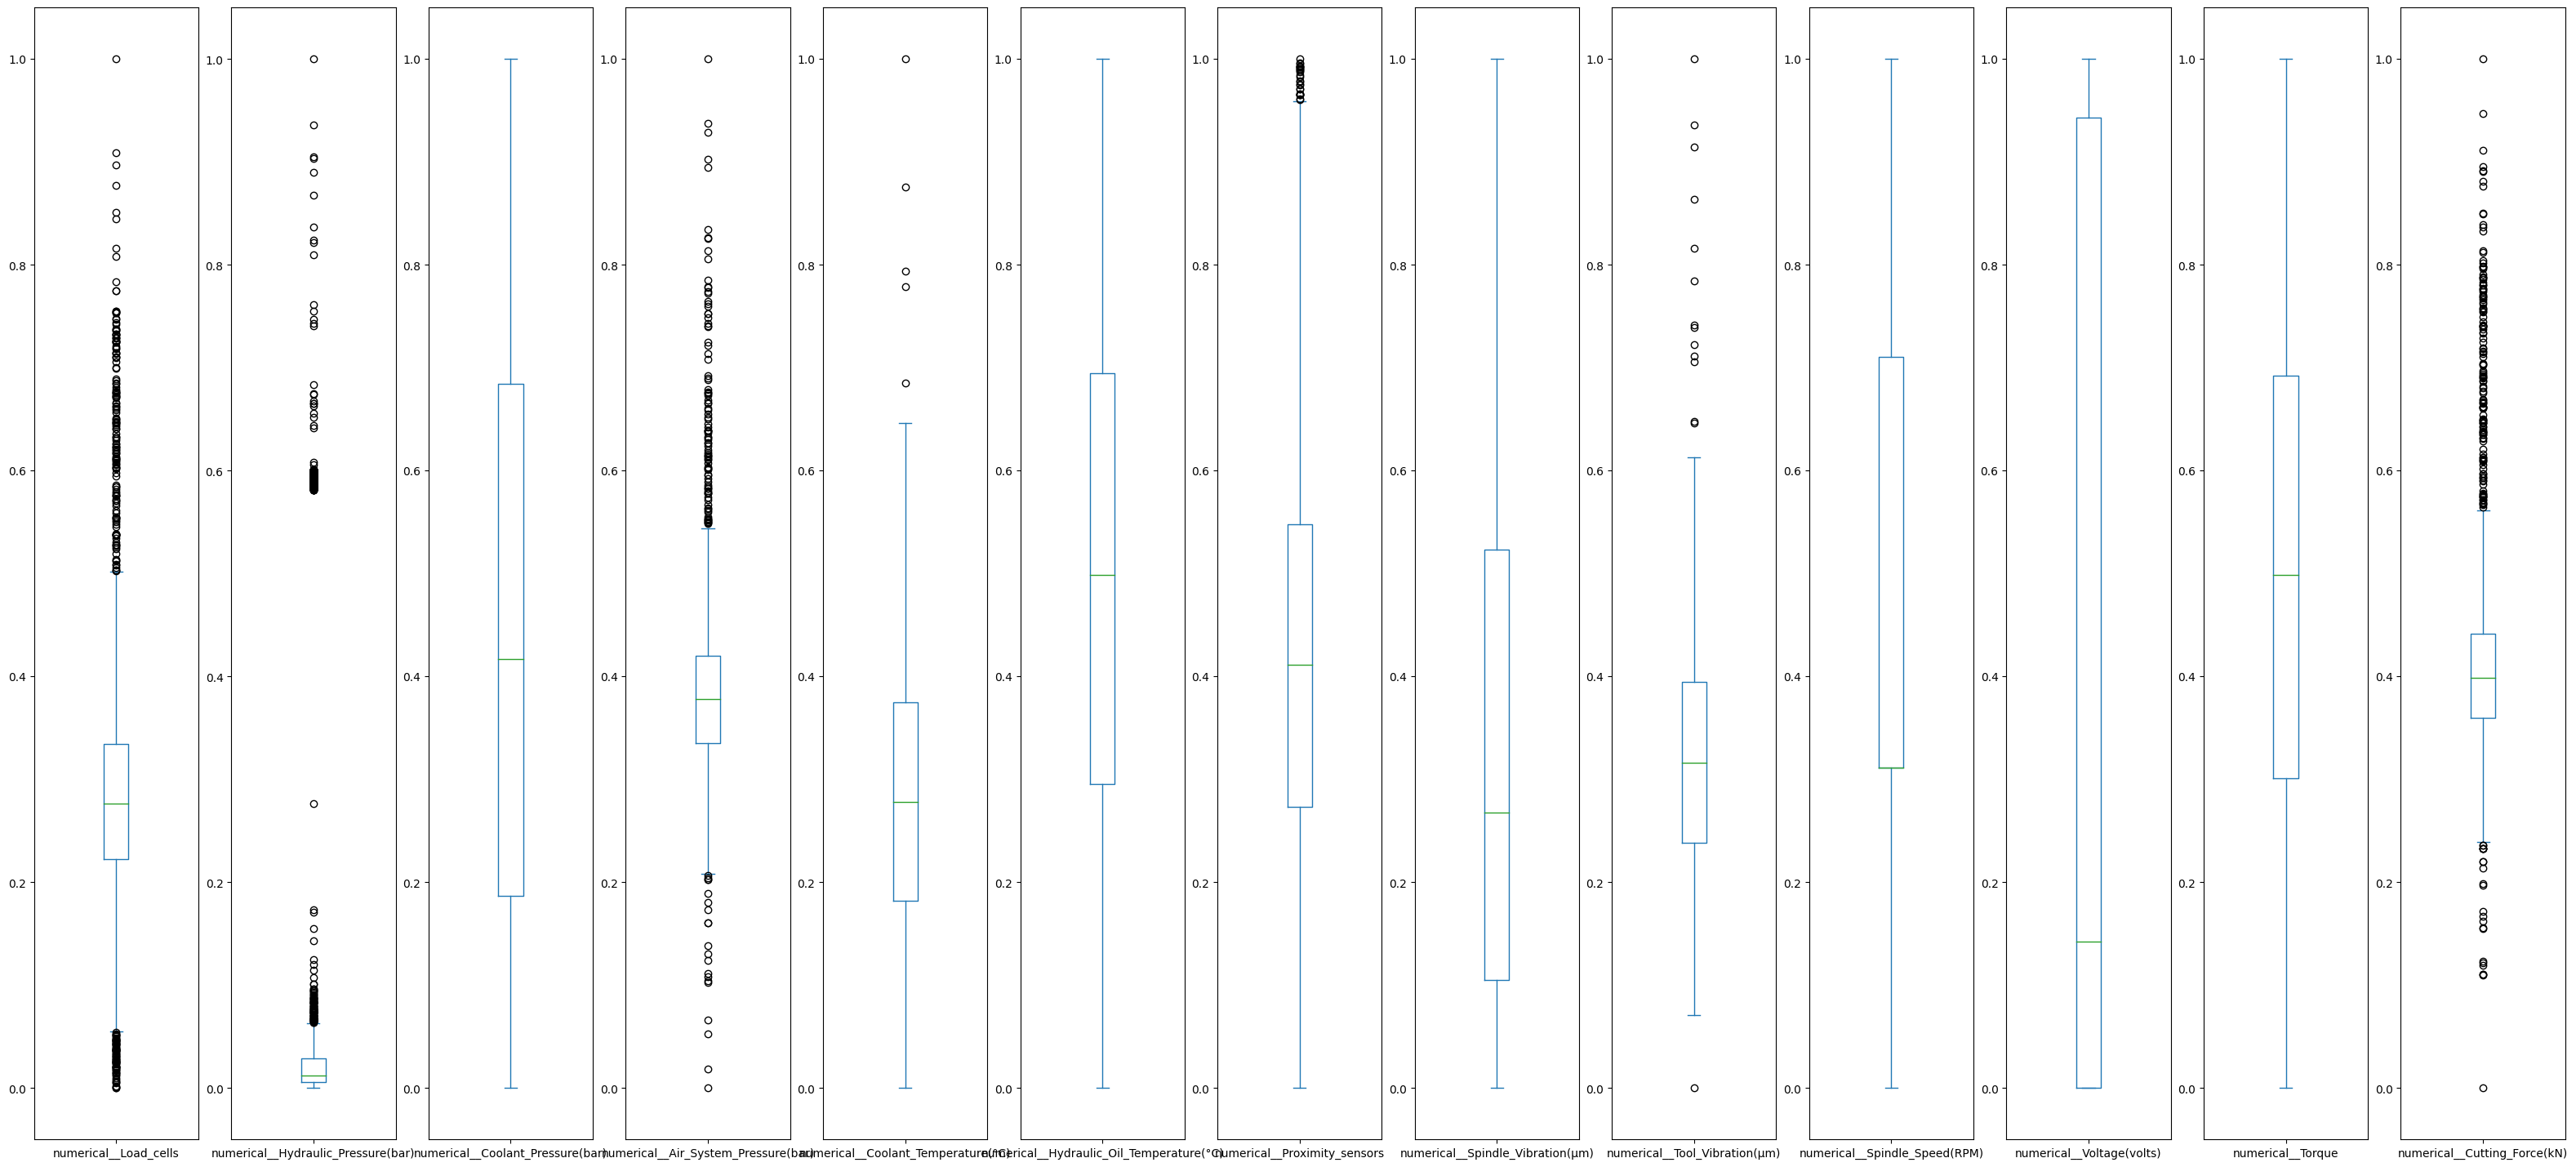

In [25]:
########## Boxplot before cleaning
ax = cleandata.plot(kind='box', subplots=True, sharey=False, figsize=(40, 18))

In [26]:
# Set x-axis labels rotation and fontsize for each subplot
for subplot in ax:
    subplot.set_xticklabels(subplot.get_xticklabels(), rotation=90, fontsize=21)

In [27]:
# Adjust the spacing between subplots
plt.subplots_adjust(wspace=1.0)
# Show the plot
plt.show()

<Figure size 640x480 with 0 Axes>

In [28]:
##########
winsor = Winsorizer(capping_method = 'iqr', # choose  IQR rule boundaries or gaussian for mean and std
                          tail = 'both', # cap left, right or both tails 
                          fold = 1.5,
                          variables = columns_list)

In [29]:
# Fit the winsorizer to numerical columns
outlier = winsor.fit(cleandata[columns_list])
# Save the fitted winsorizer model 
joblib.dump(outlier, 'winsor')
cleandata[columns_list] = outlier.transform(cleandata[columns_list])


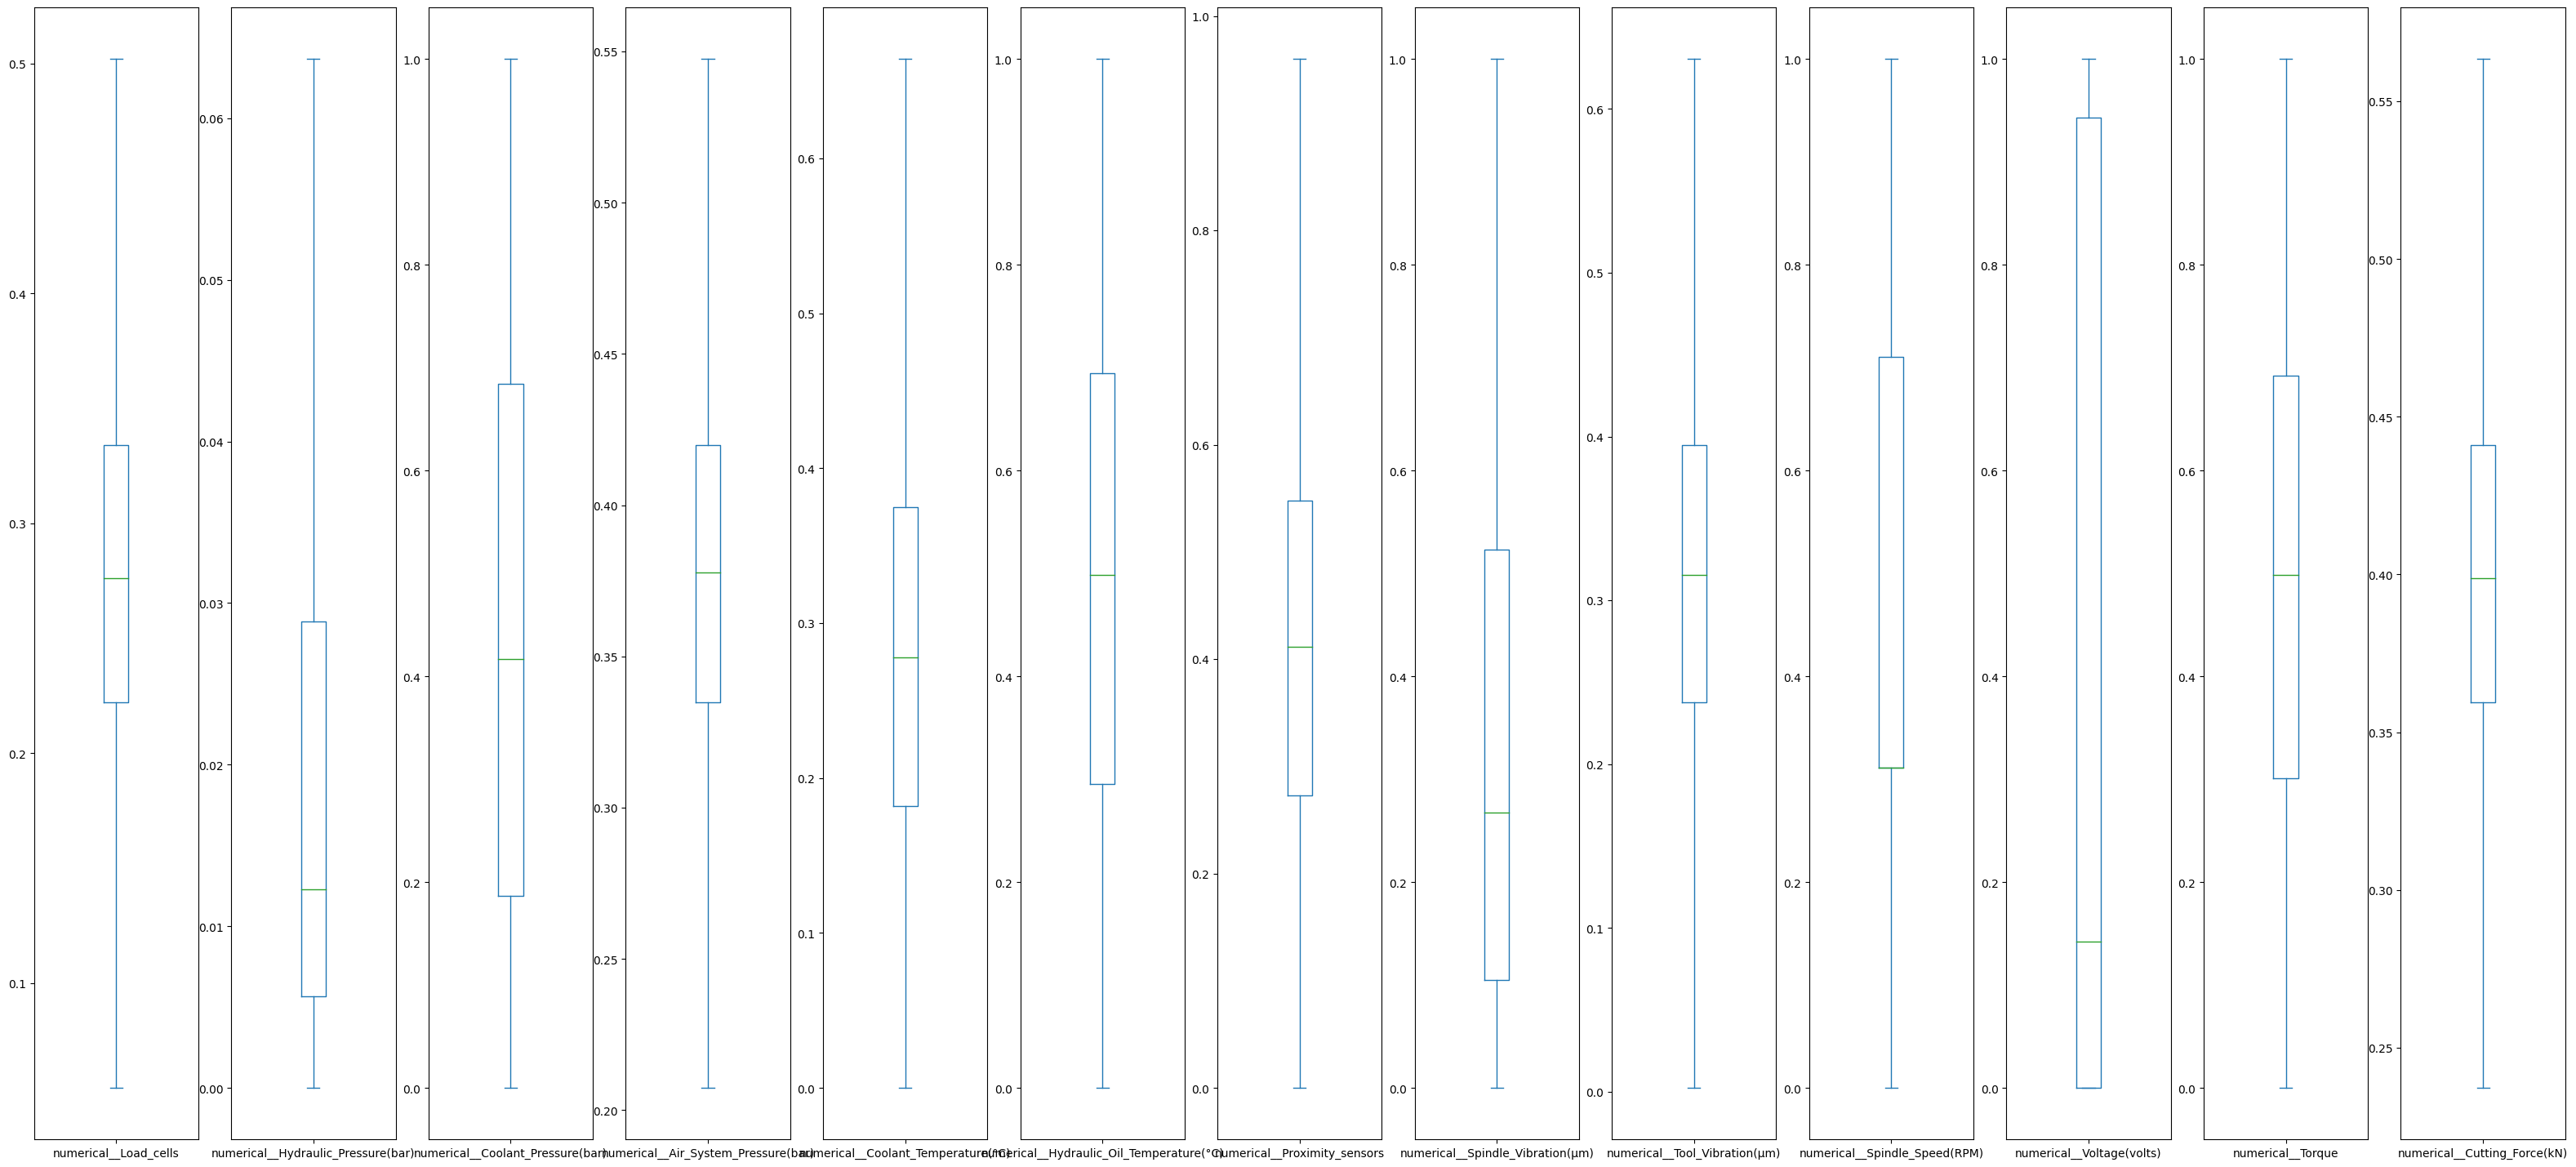

In [30]:
########## Boxplot after cleaning
ax = cleandata.plot(kind='box', subplots=True, sharey=False, figsize=(40, 18))

In [31]:
# Set x-axis labels rotation and fontsize for each subplot
for subplot in ax:
    subplot.set_xticklabels(subplot.get_xticklabels(), rotation=90, fontsize=21)

In [32]:
# Adjust the spacing between subplots
plt.subplots_adjust(wspace=1.0)
# Show the plot
plt.show()

<Figure size 640x480 with 0 Axes>

In [33]:
### check for balanced or imbalanced data
df_y['Downtime'].value_counts()

Downtime
NON_FAILURE    2400
FAILURE         300
Name: count, dtype: int64

#The ratio of NON_FAILURE to FAILURE can be calculated as:
 2400 / 300 = 8
#This means that there are 8 times more instances of NON_FAILURE than FAILURE in dataset.
#When the ratio of instances between the classes is significantly imbalanced, as in this case, 
the data is considered imbalanced.

In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(cleandata, df_y)
X_resampled.shape
y_resampled.shape
y_resampled['Downtime'].value_counts()

Downtime
NON_FAILURE    2400
FAILURE        2400
Name: count, dtype: int64

In [35]:
# split data
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 0, stratify = y_resampled)

In [36]:
# X_train, X_test, Y_train, Y_test = train_test_split(cleandata, df_y, test_size = 0.2, random_state = 0, stratify = df_y)

X_train.shape
X_test.shape
Y_train.value_counts()
Y_test.value_counts()

Downtime   
FAILURE        480
NON_FAILURE    480
Name: count, dtype: int64

In [37]:
# Model building
# Best Model
############ Naive bayes from Automl Pycarret
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [38]:
Gausian = GaussianNB(priors=None, var_smoothing=1e-09)

In [39]:
model_nb = Gausian.fit(X_train.values, Y_train.values.ravel())

In [40]:
pred = model_nb.predict(X_train.values)


In [41]:
accuracy = accuracy_score(Y_train, pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9841145833333333


In [42]:
report = classification_report(Y_train, pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

     FAILURE       0.97      1.00      0.98      1920
 NON_FAILURE       1.00      0.97      0.98      1920

    accuracy                           0.98      3840
   macro avg       0.98      0.98      0.98      3840
weighted avg       0.98      0.98      0.98      3840



In [43]:
####
pred_test = model_nb.predict(X_test.values)

In [44]:
# Evaluate the model's performance
accuracy = accuracy_score(Y_test, pred_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9864583333333333


In [45]:
report = classification_report(Y_test, pred_test)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

     FAILURE       0.97      1.00      0.99       480
 NON_FAILURE       1.00      0.97      0.99       480

    accuracy                           0.99       960
   macro avg       0.99      0.99      0.99       960
weighted avg       0.99      0.99      0.99       960



In [46]:
pickle.dump(model_nb, open('Naive_bayes.pkl','wb'))

2024-02-23 15:02:48,890 - INFO     - Executing shutdown due to inactivity...
2024-02-23 15:03:01,104 - INFO     - Executing shutdown...
2024-02-23 15:03:01,119 - ERROR    - Exception on /shutdown [GET]
Traceback (most recent call last):
  File "C:\Users\Dell\anaconda3\envs\projectml\Lib\site-packages\flask\app.py", line 2529, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\envs\projectml\Lib\site-packages\flask\app.py", line 1825, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\envs\projectml\Lib\site-packages\flask\app.py", line 1823, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\envs\projectml\Lib\site-packages\flask\app.py", line 1799, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)
        